# Linear algebra and eigenvalue problems

This notebook is the executable companion to chapter 1 of *Quantum mechanics
for Many-particle Systems*.  It contains the algorithms discussed there, in a
form you can run and modify:

1. direct solvers for linear systems -- Gaussian elimination, LU, Cholesky and
   the tridiagonal algorithm;
2. iterative solvers -- Jacobi, Gauss-Seidel, successive over-relaxation and
   the conjugate gradient method;
3. the algebraic eigenvalue problem -- Householder tridiagonalisation followed
   by the QL algorithm with implicit shifts;
4. the Lanczos algorithm, applied to a pairing-model Hamiltonian;
5. Schrödinger's equation solved by diagonalisation.

Everything is written with NumPy only.  The complete stand-alone programs live
in `doc/BookManybody/BookMaterial/Programs`.

Throughout, indices run from $0$ to $n-1$, so the formulae of the text and the
code carry the same indices.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=8, suppress=True)
rng = np.random.default_rng(2026)

## 1. Direct solvers

A direct method produces the exact answer, up to rounding, in a fixed number
of operations.  Gaussian elimination reduces $\boldsymbol{A}$ to upper
triangular form and then solves by backward substitution,

$$
x_m = \frac{1}{u_{mm}}\Big(y_m - \sum_{k=m+1}^{n-1} u_{mk}x_k\Big),
\qquad m = n-1,\dots,0 .
$$

Partial pivoting -- always using the largest element of the current column as
the pivot -- keeps all multipliers bounded by one and is what makes the method
numerically safe.

In [2]:
def gaussian_elimination(A, b):
    """Solve A x = b by Gaussian elimination with partial pivoting."""
    n = A.shape[0]
    M = A.astype(float).copy()
    y = np.asarray(b, dtype=float).copy()

    for k in range(n - 1):                       # forward elimination
        p = k + np.argmax(np.abs(M[k:, k]))      # partial pivoting
        if p != k:
            M[[k, p]] = M[[p, k]]
            y[k], y[p] = y[p], y[k]
        for i in range(k + 1, n):
            factor = M[i, k] / M[k, k]
            M[i, k:] -= factor * M[k, k:]
            y[i] -= factor * y[k]

    x = np.zeros(n)                              # backward substitution
    for m in range(n - 1, -1, -1):
        x[m] = (y[m] - M[m, m+1:] @ x[m+1:]) / M[m, m]
    return x

The LU decomposition keeps the multipliers instead of discarding them, so that
$\boldsymbol{P}\boldsymbol{A}=\boldsymbol{L}\boldsymbol{U}$.  The expensive
$\mathcal{O}(n^3)$ factorisation is then done once, and every extra right-hand
side costs only $\mathcal{O}(n^2)$.  The determinant comes for free as the
product of the diagonal elements of $\boldsymbol{U}$.

In [3]:
class LUDecomposition:
    """Doolittle LU factorisation with partial pivoting, P A = L U."""

    def __init__(self, A):
        self.n = A.shape[0]
        LU = A.astype(float).copy()
        perm = np.arange(self.n)
        sign = 1.0
        for k in range(self.n):
            p = k + np.argmax(np.abs(LU[k:, k]))
            if p != k:
                LU[[k, p]] = LU[[p, k]]
                perm[[k, p]] = perm[[p, k]]
                sign = -sign
            LU[k+1:, k] /= LU[k, k]                       # the multipliers
            LU[k+1:, k+1:] -= np.outer(LU[k+1:, k], LU[k, k+1:])
        self.LU, self.perm, self.sign = LU, perm, sign

    @property
    def L(self):
        return np.tril(self.LU, -1) + np.eye(self.n)

    @property
    def U(self):
        return np.triu(self.LU)

    def solve(self, b):
        y = np.asarray(b, dtype=float)[self.perm].copy()
        for i in range(1, self.n):                        # L y = P b
            y[i] -= self.LU[i, :i] @ y[:i]
        x = np.zeros(self.n)
        for i in range(self.n - 1, -1, -1):               # U x = y
            x[i] = (y[i] - self.LU[i, i+1:] @ x[i+1:]) / self.LU[i, i]
        return x

    def determinant(self):
        return self.sign * np.prod(np.diag(self.LU))

    def inverse(self):
        return np.column_stack([self.solve(e) for e in np.eye(self.n)])

In [4]:
n = 6
A = rng.normal(size=(n, n)) + n * np.eye(n)
b = rng.normal(size=n)
exact = np.linalg.solve(A, b)

lu = LUDecomposition(A)
print(f"Gaussian elimination   |x - x_exact| = "
      f"{np.linalg.norm(gaussian_elimination(A, b) - exact):.3e}")
print(f"LU decomposition       |x - x_exact| = "
      f"{np.linalg.norm(lu.solve(b) - exact):.3e}")
print(f"                       |P A - L U|   = "
      f"{np.linalg.norm(A[lu.perm] - lu.L @ lu.U):.3e}")
print(f"determinant  ours {lu.determinant():+.8e}   "
      f"numpy {np.linalg.det(A):+.8e}")
print(f"inverse                |A^-1 A - I|  = "
      f"{np.linalg.norm(lu.inverse() @ A - np.eye(n)):.3e}")

Gaussian elimination   |x - x_exact| = 0.000e+00
LU decomposition       |x - x_exact| = 2.776e-17
                       |P A - L U|   = 9.506e-16
determinant  ours +3.85798536e+04   numpy +3.85798536e+04
inverse                |A^-1 A - I|  = 3.918e-16


### Structure pays: the tridiagonal solver

The matrix that comes out of discretising $-u''=f$ is tridiagonal.  Solving it
with general elimination would cost $2n^3/3$ operations; the specialised
forward/backward sweep costs $\mathcal{O}(n)$.  Recognising structure is worth
more than any amount of tuning.

In [5]:
def tridiagonal_solve(a, b, c, f):
    """Solve a_i u_{i-1} + b_i u_i + c_i u_{i+1} = f_i in O(n) operations."""
    n = len(b)
    temp = np.zeros(n)
    u = np.zeros(n)

    btemp = b[0]                                  # forward substitution
    u[0] = f[0] / btemp
    for i in range(1, n):
        temp[i] = c[i-1] / btemp
        btemp = b[i] - a[i] * temp[i]
        u[i] = (f[i] - a[i] * u[i-1]) / btemp

    for i in range(n - 2, -1, -1):                # backward substitution
        u[i] -= temp[i+1] * u[i+1]
    return u


# -u'' = 2 on (0,1) with u(0)=u(1)=0; the exact solution is u(x) = x(1-x)
n = 100
h = 1.0 / (n + 1)
x = np.linspace(h, 1.0 - h, n)
u = tridiagonal_solve(np.full(n, -1/h**2), np.full(n, 2/h**2),
                      np.full(n, -1/h**2), np.full(n, 2.0))
print(f"max |u_numerical - x(1-x)| = {np.max(np.abs(u - x*(1-x))):.3e}")

max |u_numerical - x(1-x)| = 8.604e-16


## 2. Iterative solvers

Iterative methods never need the matrix itself, only the product
$\boldsymbol{A}\boldsymbol{x}$.  Splitting
$\boldsymbol{A}=\boldsymbol{D}+\boldsymbol{L}+\boldsymbol{U}$,

$$
\text{Jacobi:}\quad x_i^{(k+1)}=\frac{1}{a_{ii}}\Big(b_i-\sum_{j\neq i}a_{ij}x_j^{(k)}\Big),
$$

$$
\text{Gauss-Seidel:}\quad x_i^{(k+1)}=\frac{1}{a_{ii}}\Big(b_i-\sum_{j<i}a_{ij}x_j^{(k+1)}-\sum_{j>i}a_{ij}x_j^{(k)}\Big),
$$

and successive over-relaxation exaggerates the Gauss-Seidel step by a factor
$\omega$.  The conjugate gradient method takes a different route: it minimises
$P(\boldsymbol{x})=\tfrac12\boldsymbol{x}^T\boldsymbol{A}\boldsymbol{x}-\boldsymbol{x}^T\boldsymbol{b}$
along directions that are conjugate,
$\boldsymbol{p}_i^T\boldsymbol{A}\boldsymbol{p}_j=0$.

In [6]:
def jacobi(A, b, tol=1e-8, max_iter=100000):
    d = np.diag(A)
    R = A - np.diag(d)
    x = np.zeros_like(b)
    hist = []
    for k in range(max_iter):
        x = (b - R @ x) / d
        hist.append(np.linalg.norm(b - A @ x))
        if hist[-1] < tol:
            break
    return x, hist


def gauss_seidel(A, b, omega=1.0, tol=1e-8, max_iter=100000):
    """omega = 1 is Gauss-Seidel; 1 < omega < 2 is over-relaxation."""
    n = len(b)
    x = np.zeros_like(b)
    hist = []
    for k in range(max_iter):
        for i in range(n):
            s = A[i, :i] @ x[:i] + A[i, i+1:] @ x[i+1:]
            x[i] = (1 - omega) * x[i] + omega * (b[i] - s) / A[i, i]
        hist.append(np.linalg.norm(b - A @ x))
        if hist[-1] < tol:
            break
    return x, hist


def conjugate_gradient(matvec, b, tol=1e-8, max_iter=None):
    """Only the product A p is used, so matvec may be matrix-free."""
    n = len(b)
    max_iter = n if max_iter is None else max_iter
    x = np.zeros_like(b)
    r = b - matvec(x)
    p = r.copy()
    rs = r @ r
    hist = [np.sqrt(rs)]
    for k in range(max_iter):
        Ap = matvec(p)
        alpha = rs / (p @ Ap)
        x += alpha * p                   # x_{k+1} = x_k + alpha_k p_k
        r -= alpha * Ap                  # r_{k+1} = r_k - alpha_k A p_k
        rs_new = r @ r
        hist.append(np.sqrt(rs_new))
        if hist[-1] < tol:
            break
        p = r + (rs_new / rs) * p        # beta_k = |r_{k+1}|^2/|r_k|^2
        rs = rs_new
    return x, hist

In [7]:
n = 30
h = 1.0 / (n + 1)
A = (np.diag(np.full(n, 2.0)) + np.diag(np.full(n-1, -1.0), 1)
     + np.diag(np.full(n-1, -1.0), -1)) / h**2
xg = np.linspace(h, 1-h, n)
b = np.full(n, 2.0)
exact = xg * (1 - xg)

results = {}
results["Jacobi"] = jacobi(A, b)
results["Gauss-Seidel"] = gauss_seidel(A, b, omega=1.0)
results["SOR, omega=1.8"] = gauss_seidel(A, b, omega=1.8)
results["Conjugate gradient"] = conjugate_gradient(lambda v: A @ v, b)

print(f"{'method':22s} {'iterations':>12s} {'|x - exact|':>16s}")
print("-" * 52)
for name, (x, hist) in results.items():
    print(f"{name:22s} {len(hist):12d} {np.linalg.norm(x - exact):16.3e}")

method                   iterations      |x - exact|


----------------------------------------------------
Jacobi                         4030        1.009e-09
Gauss-Seidel                   2016        1.003e-09
SOR, omega=1.8                  170        4.857e-10
Conjugate gradient               16        2.168e-16


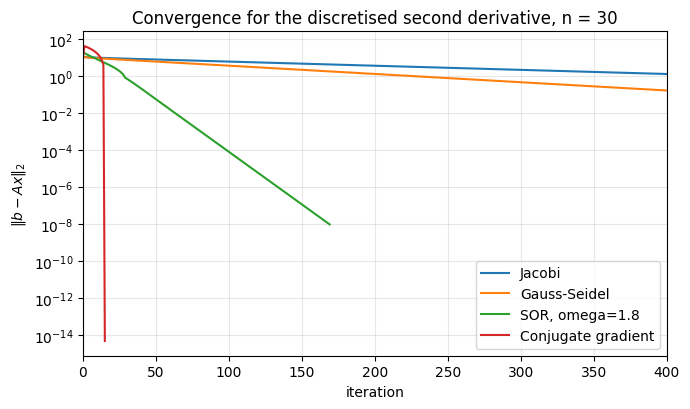

In [8]:
plt.figure(figsize=(7, 4.2))
for name, (x, hist) in results.items():
    plt.semilogy(hist, label=name)
plt.xlabel("iteration")
plt.ylabel(r"$\|b - Ax\|_2$")
plt.title(f"Convergence for the discretised second derivative, n = {n}")
plt.xlim(0, 400)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 3. The eigenvalue problem: Householder and QL

A real symmetric matrix is diagonalised in two steps.  First a sequence of
Householder reflectors $\boldsymbol{P}=\boldsymbol{I}-2\boldsymbol{u}\boldsymbol{u}^T$
reduces $\boldsymbol{A}$ to tridiagonal form,
$\boldsymbol{T}=\boldsymbol{S}^T\boldsymbol{A}\boldsymbol{S}$.  Since this is
a similarity transformation the eigenvalues are untouched.  The sign of

$$
\kappa = -\mathrm{sign}(v_0)\,\|\boldsymbol{v}\|_2
$$

is chosen so that the subtraction $\boldsymbol{v}-\kappa\boldsymbol{e}$ never
suffers cancellation.  Second, the tridiagonal matrix is diagonalised by the
QL algorithm with implicit Wilkinson shifts.

In [9]:
def householder_tridiagonalize(A, tol=1e-14):
    """Return (d, e, S) with S^T A S tridiagonal."""
    n = A.shape[0]
    M = A.astype(float).copy()
    S = np.eye(n)
    for k in range(n - 2):
        v = M[k+1:, k]
        norm_v = np.linalg.norm(v)
        if norm_v < tol:
            continue
        kappa = -np.copysign(norm_v, v[0])   # avoids cancellation
        w = v.copy()
        w[0] -= kappa
        u = w / np.linalg.norm(w)

        block = M[k+1:, k+1:]                # P A P = A - 2 z u^T - 2 u z^T
        p = block @ u
        z = p - (u @ p) * u
        M[k+1:, k+1:] = block - 2*np.outer(z, u) - 2*np.outer(u, z)

        M[k+1:, k] = 0.0
        M[k+1, k] = kappa
        M[k, k+1:] = 0.0
        M[k, k+1] = kappa
        S[:, k+1:] -= 2 * np.outer(S[:, k+1:] @ u, u)     # S <- S P
    return np.diag(M).copy(), np.diag(M, -1).copy(), S

In [10]:
def tqli(d, e, z=None, max_sweeps=50):
    """QL algorithm with implicit shifts for a symmetric tridiagonal matrix."""
    d = np.asarray(d, dtype=float).copy()
    n = len(d)
    e = np.concatenate([np.asarray(e, dtype=float), [0.0]])
    z = np.eye(n) if z is None else np.asarray(z, dtype=float).copy()
    eps = np.finfo(float).eps

    for l in range(n):
        for _ in range(max_sweeps):
            m = n - 1                          # find a negligible element
            for i in range(l, n - 1):
                if abs(e[i]) <= eps * (abs(d[i]) + abs(d[i+1])):
                    m = i
                    break
            if m == l:
                break
            g = (d[l+1] - d[l]) / (2.0 * e[l])          # Wilkinson shift
            r = np.hypot(g, 1.0)
            g = d[m] - d[l] + e[l] / (g + np.copysign(r, g))
            s = c = 1.0
            p = 0.0
            for i in range(m - 1, l - 1, -1):
                f, bb = s * e[i], c * e[i]
                r = np.hypot(f, g)
                e[i+1] = r
                s, c = f / r, g / r
                g = d[i+1] - p
                r = (d[i] - g) * s + 2.0 * c * bb
                p = s * r
                d[i+1] = g + p
                g = c * r - bb
                col = z[:, i+1].copy()
                z[:, i+1] = s * z[:, i] + c * col
                z[:, i] = c * z[:, i] - s * col
            d[l] -= p
            e[l] = g
            e[m] = 0.0
    order = np.argsort(d)
    return d[order], z[:, order]

In [11]:
n = 8
M = rng.normal(size=(n, n))
A = 0.5 * (M + M.T)

d, e, S = householder_tridiagonalize(A)
T = np.diag(d) + np.diag(e, 1) + np.diag(e, -1)
print(f"|S^T S - I|   = {np.linalg.norm(S.T @ S - np.eye(n)):.3e}")
print(f"|S T S^T - A| = {np.linalg.norm(S @ T @ S.T - A):.3e}")

values, vectors = tqli(d, e, S)
reference = np.linalg.eigvalsh(A)
print()
print("eigenvalues, Householder + QL:", values)
print("eigenvalues, numpy          :", reference)
print(f"max deviation     = {np.max(np.abs(values - reference)):.3e}")
print(f"|A V - V diag(l)| = "
      f"{np.linalg.norm(A @ vectors - vectors @ np.diag(values)):.3e}")

|S^T S - I|   = 9.806e-16
|S T S^T - A| = 2.747e-15

eigenvalues, Householder + QL: [-4.28864482 -2.53848701 -1.05594757  0.28544745  0.61452604  1.6427293
  2.02230253  3.41003844]
eigenvalues, numpy          : [-4.28864482 -2.53848701 -1.05594757  0.28544745  0.61452604  1.6427293
  2.02230253  3.41003844]
max deviation     = 3.109e-15
|A V - V diag(l)| = 5.190e-15


## 4. The Lanczos algorithm

For a many-body Hamiltonian the matrix is far too large to store, but the
product $\boldsymbol{A}\boldsymbol{q}$ is always available.  The Lanczos
algorithm exploits exactly this.  It builds an orthonormal basis of the Krylov
space

$$
\mathcal{K}_m(\boldsymbol{A},\boldsymbol{q}_0)=\mathrm{span}\{\boldsymbol{q}_0,\boldsymbol{A}\boldsymbol{q}_0,\dots,\boldsymbol{A}^{m-1}\boldsymbol{q}_0\}
$$

through the three-term recurrence

$$
\boldsymbol{A}\boldsymbol{q}_k=\beta_{k-1}\boldsymbol{q}_{k-1}+\alpha_k\boldsymbol{q}_k+\beta_k\boldsymbol{q}_{k+1},
\qquad \alpha_k=\boldsymbol{q}_k^T\boldsymbol{A}\boldsymbol{q}_k .
$$

In that basis $\boldsymbol{A}$ is a small tridiagonal matrix whose eigenvalues,
the Ritz values, converge rapidly to the extremal eigenvalues of
$\boldsymbol{A}$.

In [12]:
def lanczos(matvec, n, m, q0=None, reorthogonalize=True, tol=1e-12):
    """m Lanczos steps; returns the tridiagonal elements and the basis."""
    q = rng.normal(size=n) if q0 is None else np.asarray(q0, float).copy()
    q /= np.linalg.norm(q)

    Q = np.zeros((n, m))
    alpha = np.zeros(m)
    beta = np.zeros(max(m - 1, 0))
    q_prev = np.zeros(n)
    b_prev = 0.0

    for k in range(m):
        Q[:, k] = q
        w = matvec(q)                              # the only use made of A
        alpha[k] = q @ w
        w = w - alpha[k] * q - b_prev * q_prev     # r_k

        if reorthogonalize:                        # cures the ghost states
            for _ in range(2):
                w -= Q[:, :k+1] @ (Q[:, :k+1].T @ w)

        if k == m - 1:
            break
        b = np.linalg.norm(w)
        if b < tol:                                # invariant subspace
            alpha, beta, Q = alpha[:k+1], beta[:k], Q[:, :k+1]
            break
        beta[k] = b
        q_prev, b_prev = q, b
        q = w / b
    return alpha, beta, Q


def ritz(matvec, n, m, reorthogonalize=True):
    alpha, beta, Q = lanczos(matvec, n, m, reorthogonalize=reorthogonalize)
    theta, y = tqli(alpha, beta)
    return theta, Q @ y, Q

### A many-body test case: the pairing model

We use the pairing Hamiltonian of the course,

$$
H = \delta\sum_p (p-1) N_p - g\sum_{pq} P_p^{\dagger}P_q ,
$$

with doubly degenerate levels $p=1,\dots,L$.  In the space with no broken
pairs a basis state is a choice of which levels carry a pair, so the dimension
is $\binom{L}{n}$.  Two configurations that differ by moving one pair are
coupled by $-g$.

In [13]:
from itertools import combinations


def pairing_hamiltonian(levels=12, pairs=6, delta=1.0, g=0.5):
    basis = list(combinations(range(1, levels + 1), pairs))
    index = {c: i for i, c in enumerate(basis)}
    dim = len(basis)
    H = np.zeros((dim, dim))
    for c, i in index.items():
        H[i, i] = 2.0 * delta * sum(p - 1 for p in c) - g * pairs
        occupied = set(c)
        for p in c:                                   # move a pair from p
            for q in range(1, levels + 1):            # to an empty level q
                if q in occupied:
                    continue
                H[index[tuple(sorted(occupied - {p} | {q}))], i] -= g
    return H


H = pairing_hamiltonian()
dim = H.shape[0]
exact = np.linalg.eigvalsh(H)
print(f"dimension of the pairing matrix: {dim}")
print(f"exact ground-state energy      : {exact[0]:.12f}")

dimension of the pairing matrix: 924
exact ground-state energy      : 24.839172748451


In [14]:
print(f"{'m':>4s} {'lowest Ritz value':>22s} {'error':>12s} "
      f"{'second':>18s} {'error':>12s}")
print("-" * 72)
steps, errors = [], []
for m in (5, 10, 20, 30, 40):
    theta, _, _ = ritz(lambda v: H @ v, dim, m)
    steps.append(m)
    errors.append(abs(theta[0] - exact[0]))
    print(f"{m:4d} {theta[0]:22.12f} {abs(theta[0]-exact[0]):12.2e} "
          f"{theta[1]:18.10f} {abs(theta[1]-exact[1]):12.2e}")
print("-" * 72)
print(f"{'exact':>4s} {exact[0]:22.12f} {'':12s} {exact[1]:18.10f}")

   m      lowest Ritz value        error             second        error
------------------------------------------------------------------------
   5        34.361844534347     9.52e+00      48.1081114733     2.02e+01
  10        25.090067574237     2.51e-01      32.3434156367     4.44e+00
  20        24.839291576387     1.19e-04      27.9192438101     1.45e-02
  30        24.839172748614     1.63e-10      27.9047375614     2.08e-06
  40        24.839172748451     3.55e-15      27.9047354807     6.07e-11
------------------------------------------------------------------------
exact        24.839172748451                   27.9047354806


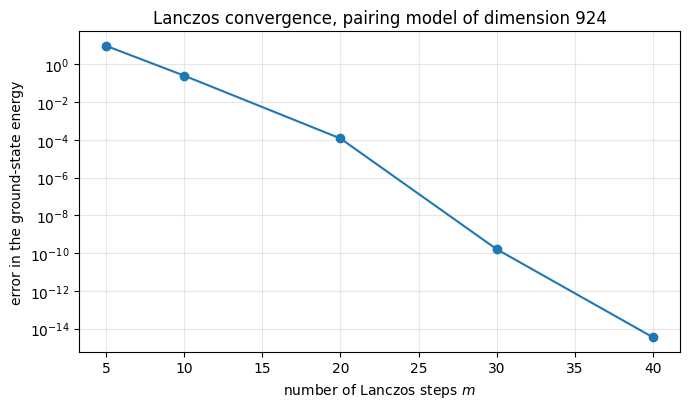

In [15]:
plt.figure(figsize=(7, 4.2))
plt.semilogy(steps, np.maximum(errors, 1e-16), "o-")
plt.xlabel("number of Lanczos steps $m$")
plt.ylabel("error in the ground-state energy")
plt.title(f"Lanczos convergence, pairing model of dimension {dim}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Loss of orthogonality

In exact arithmetic the three-term recurrence produces orthogonal vectors by
itself.  In floating-point arithmetic it does not: as soon as one Ritz value
converges, its direction creeps back into the remainder and the algorithm
starts reporting spurious extra copies of eigenvalues it has already found.
Compare the two runs below.

In [16]:
for flag in (True, False):
    theta, _, Q = ritz(lambda v: H @ v, dim, 120, reorthogonalize=flag)
    dev = np.linalg.norm(Q.T @ Q - np.eye(Q.shape[1]))
    copies = int(np.sum(np.abs(theta - exact[0]) < 1e-8))
    print(f"reorthogonalize = {str(flag):5s}:  |Q^T Q - I| = {dev:9.2e},"
          f"   copies of the ground state: {copies}")

reorthogonalize = True :  |Q^T Q - I| =  8.45e-15,   copies of the ground state: 1
reorthogonalize = False:  |Q^T Q - I| =  5.05e+00,   copies of the ground state: 3


## 5. Schrödinger's equation by diagonalisation

With the three-point formula for the second derivative, the one-dimensional
equation

$$
-\frac{d^2u}{dx^2} + x^2 u(x) = 2E\,u(x)
$$

becomes the tridiagonal eigenvalue problem

$$
\Big(\frac{2}{h^2}+V_i\Big)u_i - \frac{u_{i+1}}{h^2} - \frac{u_{i-1}}{h^2}
   = 2E\,u_i .
$$

The boundary conditions $u(R_{\min})=u(R_{\max})=0$ are imposed by leaving the
endpoints out of the matrix.  The exact eigenvalues are $2E_k = 2k+1$.

In [17]:
class SchrodingerDiagonalization:
    """Discretise -u'' + V(x) u = 2E u and diagonalise the result."""

    def __init__(self, potential, rmin=-10.0, rmax=10.0, nsteps=400):
        self.potential = potential
        self.h = (rmax - rmin) / nsteps
        self.x = rmin + self.h * np.arange(1, nsteps)   # interior points only
        self.n = len(self.x)

    @property
    def diagonal(self):
        return 2.0 / self.h**2 + self.potential(self.x)

    @property
    def offdiagonal(self):
        return np.full(self.n - 1, -1.0 / self.h**2)

    def matvec(self, v):
        """Apply the Hamiltonian without ever forming the matrix."""
        w = self.diagonal * v
        w[:-1] -= v[1:] / self.h**2
        w[1:] -= v[:-1] / self.h**2
        return w

    def solve(self, k=5):
        values, vectors = tqli(self.diagonal, self.offdiagonal)
        return values[:k], self._normalise(vectors[:, :k])

    def solve_lanczos(self, k=3, m=200):
        theta, vectors, _ = ritz(self.matvec, self.n, m)
        return theta[:k], self._normalise(vectors[:, :k])

    def _normalise(self, vectors):
        """Trapezoidal rule: h * sum |u_i|^2 = 1."""
        vectors = vectors / np.sqrt(self.h * np.sum(vectors**2, axis=0))
        for j in range(vectors.shape[1]):
            if vectors[np.argmax(np.abs(vectors[:, j])), j] < 0:
                vectors[:, j] *= -1
        return vectors

In [18]:
harmonic = lambda x: x**2
truth = np.array([1.0, 3.0, 5.0, 7.0, 9.0])

print(f"{'N':>7s} {'2E_0':>16s} {'2E_1':>16s} {'2E_2':>16s} {'max error':>12s}")
print("-" * 72)
for nsteps in (100, 200, 400, 800):
    values, _ = SchrodingerDiagonalization(harmonic, -10, 10, nsteps).solve(5)
    print(f"{nsteps:7d} {values[0]:16.10f} {values[1]:16.10f} "
          f"{values[2]:16.10f} {np.max(np.abs(values - truth)):12.2e}")
print("-" * 72)
print(f"{'exact':>7s} {truth[0]:16.10f} {truth[1]:16.10f} {truth[2]:16.10f}")
print()
print("Doubling N divides the error by four: the O(h^2) truncation error")
print("of the three-point formula, exactly as expected.")

      N             2E_0             2E_1             2E_2    max error
------------------------------------------------------------------------


    100     0.9974937026     2.9874430342     4.9672772610     1.04e-01


    200     0.9993746086     2.9968714733     4.9918612670     2.57e-02


    400     0.9998437256     2.9992185301     4.9979678946     6.41e-03


    800     0.9999609360     2.9998046738     4.9994921341     1.60e-03
------------------------------------------------------------------------
  exact     1.0000000000     3.0000000000     5.0000000000

Doubling N divides the error by four: the O(h^2) truncation error
of the three-point formula, exactly as expected.


In [19]:
problem = SchrodingerDiagonalization(harmonic, -10, 10, 400)
direct, u_direct = problem.solve(3)
ritz_values, _ = problem.solve_lanczos(3, m=200)

print(f"{'state':>7s} {'QL (direct)':>18s} {'Lanczos':>18s} {'difference':>14s}")
for j in range(3):
    print(f"{j:7d} {direct[j]:18.10f} {ritz_values[j]:18.10f} "
          f"{abs(direct[j]-ritz_values[j]):14.2e}")

  state        QL (direct)            Lanczos     difference
      0       0.9998437256       0.9998437256       5.30e-13
      1       2.9992185301       2.9992185301       4.59e-13
      2       4.9979678946       4.9979678946       1.51e-11


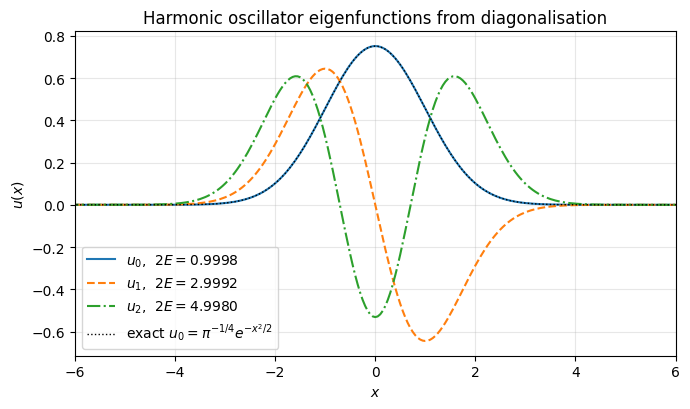

In [20]:
x = problem.x
plt.figure(figsize=(7, 4.2))
for j, style in zip(range(3), ("-", "--", "-.")):
    plt.plot(x, u_direct[:, j], style, label=fr"$u_{j}$,  $2E={direct[j]:.4f}$")
plt.plot(x, np.pi**-0.25 * np.exp(-x**2 / 2), "k:", lw=1,
         label=r"exact $u_0=\pi^{-1/4}e^{-x^2/2}$")
plt.xlim(-6, 6)
plt.xlabel("$x$")
plt.ylabel("$u(x)$")
plt.title("Harmonic oscillator eigenfunctions from diagonalisation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 6. The singular value decomposition

Everything above assumed a square matrix, and mostly a symmetric one.  Many
objects in many-body physics are neither: the coefficients of a state across a
bipartition, a set of sampled wave functions, the two-body matrix elements in a
composite pair index.  The SVD handles all of them.

Any $m\times n$ matrix can be written

$$
\boldsymbol{X} = \boldsymbol{U}\boldsymbol{\Sigma}\boldsymbol{V}^T ,
\qquad
\sigma_0 \ge \sigma_1 \ge \dots \ge 0 ,
$$

with $\boldsymbol{U}$ and $\boldsymbol{V}$ orthogonal.  It always exists — even
for a defective matrix that cannot be diagonalised at all.  The right singular
vectors are the eigenvectors of $\boldsymbol{X}^T\boldsymbol{X}$ and the left
ones those of $\boldsymbol{X}\boldsymbol{X}^T$, both with eigenvalues
$\sigma_i^2$.  Those two products will turn out to be the reduced density
matrices of a bipartite state.

In [21]:
X = np.array([[1.0, -1.0], [1.0, -1.0]])
U, sigma, Vt = np.linalg.svd(X)

print("X =\n", X)
print(f"det(X) = {np.linalg.det(X):.1f}   -> X is singular")
print(f"X X^T == X^T X ? {np.allclose(X @ X.T, X.T @ X)}  -> not normal, "
      f"so X cannot be diagonalised")
print()
print("singular values:", np.round(sigma, 12))
print("U =\n", np.round(U, 8))
print("V^T =\n", np.round(Vt, 8))
print(f"\n|U Sigma V^T - X| = "
      f"{np.linalg.norm((U * sigma) @ Vt - X):.3e}")

X =
 [[ 1. -1.]
 [ 1. -1.]]
det(X) = 0.0   -> X is singular
X X^T == X^T X ? False  -> not normal, so X cannot be diagonalised

singular values: [2. 0.]
U =
 [[-0.70710678 -0.70710678]
 [-0.70710678  0.70710678]]
V^T =
 [[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]

|U Sigma V^T - X| = 5.979e-16


### Never form $\boldsymbol{X}^T\boldsymbol{X}$

Since $\sigma_i^2$ are the eigenvalues of $\boldsymbol{X}^T\boldsymbol{X}$, one
could compute singular values by diagonalising that product.  It is correct
mathematically and poor numerically: forming the product squares the condition
number, so half the significant digits are gone before the eigenvalue solver is
called.

In [22]:
Q, _ = np.linalg.qr(rng.normal(size=(60, 12)))
P, _ = np.linalg.qr(rng.normal(size=(12, 12)))
sigma_true = np.logspace(0, -7, 12)
X = (Q * sigma_true) @ P.T

direct = np.linalg.svd(X, compute_uv=False)
naive = np.sqrt(np.maximum(np.linalg.eigvalsh(X.T @ X)[::-1], 0.0))

print(f"{'exact sigma':>16s} {'from SVD':>16s} {'from X^T X':>16s} "
      f"{'rel. error':>13s}")
for k in (0, 5, 9, 10, 11):
    print(f"{sigma_true[k]:16.8e} {direct[k]:16.8e} {naive[k]:16.8e} "
          f"{abs(naive[k]-sigma_true[k])/sigma_true[k]:13.2e}")
print(f"\nkappa(X)     = {direct[0]/direct[-1]:.2e}")
print(f"kappa(X^T X) = {(direct[0]/direct[-1])**2:.2e}")

     exact sigma         from SVD       from X^T X    rel. error
  1.00000000e+00   1.00000000e+00   1.00000000e+00      2.22e-16
  6.57933225e-04   6.57933225e-04   6.57933225e-04      5.56e-13
  1.87381742e-06   1.87381742e-06   1.87381780e-06      2.01e-07
  4.32876128e-07   4.32876128e-07   4.32886254e-07      2.34e-05
  1.00000000e-07   1.00000000e-07   9.99634486e-08      3.66e-04

kappa(X)     = 1.00e+07
kappa(X^T X) = 1.00e+14


### Rank, the pseudoinverse and near-linearly-dependent bases

The rank is the number of non-zero singular values, and the condition number is
$\kappa_2=\sigma_0/\sigma_{r-1}$.  When a matrix is singular or nearly so, the
Moore-Penrose pseudoinverse

$$
\boldsymbol{X}^{+} = \boldsymbol{V}\boldsymbol{\Sigma}^{+}\boldsymbol{U}^{T}
$$

replaces the inverse: the reciprocals of the singular values are taken only
above a threshold, and the rest are set to zero rather than inverted.

Many-body calculations use non-orthogonal bases — Gaussians, oscillator states
of different length, generator coordinates — which become linearly dependent
long before one would like.  The generalised problem
$\boldsymbol{H}\boldsymbol{c}=E\boldsymbol{S}\boldsymbol{c}$ is reduced to an
ordinary one by $\boldsymbol{X}=\boldsymbol{V}\boldsymbol{s}^{-1/2}$, which
involves $s_i^{-1/2}$ and so breaks down exactly where an overlap eigenvalue is
tiny.  Canonical orthogonalisation discards those directions first.

In [23]:
def gaussian_basis(n_orb=12, n_grid=200, rmax=4.0, width=1.4, softening=0.5):
    """Overlap matrix and two-body matrix elements for overlapping Gaussians."""
    h = 2.0 * rmax / (n_grid - 1)
    x = np.linspace(-rmax, rmax, n_grid)
    centres = np.linspace(-rmax * 0.8, rmax * 0.8, n_orb)

    phi = np.exp(-(x[None, :] - centres[:, None])**2 / (2.0 * width**2))
    phi /= np.sqrt(h * np.sum(phi**2, axis=1))[:, None]

    S = h * (phi @ phi.T)                                    # overlap
    rho = (phi[:, None, :] * phi[None, :, :]).reshape(n_orb*n_orb, n_grid)
    K = 1.0 / np.sqrt((x[:, None] - x[None, :])**2 + softening**2)
    V = h**2 * (rho @ K @ rho.T)                             # pair supermatrix
    return S, V


def canonical_orthogonalization(S, threshold=1e-8):
    """X = V s^{-1/2}, keeping only eigenvalues above threshold * s_max."""
    w, V = np.linalg.eigh(S)
    order = np.argsort(w)[::-1]
    w, V = w[order], V[:, order]
    keep = w > threshold * w[0]
    return V[:, keep] / np.sqrt(w[keep]), w, int(np.sum(keep))


S, V2b = gaussian_basis()
_, w, _ = canonical_orthogonalization(S, 0.0)
print(f"{S.shape[0]} Gaussians, condition number of S: {w[0]/w[-1]:.3e}")
print("eigenvalues of S:")
print(" ", " ".join(f"{v:.2e}" for v in w))
print()
for thr in (0.0, 1e-12, 1e-8, 1e-5):
    _, _, kept = canonical_orthogonalization(S, thr)
    print(f"threshold {thr:8.0e}:  kept {kept:2d} of {S.shape[0]}"
          f"   effective kappa = {w[0]/w[kept-1]:9.2e}")

12 Gaussians, condition number of S: 1.061e+13
eigenvalues of S:
  6.93e+00 3.61e+00 1.17e+00 2.43e-01 3.35e-02 3.19e-03 2.13e-04 1.01e-05 3.32e-07 7.37e-09 1.01e-10 6.54e-13

threshold    0e+00:  kept 12 of 12   effective kappa =  1.06e+13
threshold    1e-12:  kept 11 of 12   effective kappa =  6.87e+10
threshold    1e-08:  kept  9 of 12   effective kappa =  2.09e+07
threshold    1e-05:  kept  7 of 12   effective kappa =  3.25e+04


### Low-rank approximation and the Schmidt decomposition

Truncating

$$
\boldsymbol{X} = \sum_k \sigma_k\,\boldsymbol{u}_k\boldsymbol{v}_k^{T}
$$

after $\chi$ terms gives, by the Eckart-Young theorem, the *best* rank-$\chi$
approximation, with error exactly $\sigma_\chi$ in the 2-norm.

For a state split into parts $A$ and $B$,
$|\Psi\rangle=\sum_{ij}C_{ij}|i\rangle_A|j\rangle_B$, the SVD of
$\boldsymbol{C}$ gives the **Schmidt decomposition**

$$
|\Psi\rangle = \sum_k \sigma_k\,|u_k\rangle_A |v_k\rangle_B ,
$$

the reduced density matrices are
$\rho_A=\boldsymbol{C}\boldsymbol{C}^T$ and
$\rho_B=\boldsymbol{C}^T\boldsymbol{C}$ with the *same* eigenvalues
$\sigma_k^2$, and the entanglement entropy is
$S=-\sum_k\sigma_k^2\ln\sigma_k^2$.  A Schmidt rank of one means a product
state.  The discarded weight $\sum_{k\ge\chi}\sigma_k^2$ is precisely the DMRG
truncation error, and $\chi$ its bond dimension.

In [24]:
class SchmidtDecomposition:
    """The SVD of a bipartitioned state vector."""

    def __init__(self, C):
        self.C = np.asarray(C, dtype=float)
        self.U, self.sigma, self.Vt = np.linalg.svd(C, full_matrices=False)
        self.weights = self.sigma**2       # normalised: sum_k sigma_k^2 = 1

    def schmidt_rank(self, tol=1e-10):
        return int(np.sum(self.sigma > tol * self.sigma[0]))

    def entanglement_entropy(self, base=np.e):
        w = self.weights[self.weights > 1e-16]
        entropy = -np.sum(w * np.log(w)) / np.log(base)
        return float(entropy) if entropy > 0.0 else 0.0

    def truncation_error(self, k):
        """Weight discarded when only k Schmidt states are kept."""
        return float(np.sum(self.weights[k:]))

    def states_for(self, tol):
        return 1 + int(np.argmax(np.cumsum(self.weights) > 1.0 - tol))

#### The pairing model across a cut

Split the twelve levels of the pairing model into the lowest six and the
highest six.  A seniority-zero basis state is a set of occupied levels, which
factorises into its part in $A$ and its part in $B$, so the coefficients form a
$64\times 64$ matrix whose singular values are the Schmidt coefficients across
the cut.  This is exactly the object a DMRG sweep truncates.

In [25]:
def pairing_bipartition(levels=12, pairs=6, delta=1.0, g=0.5):
    """Ground state of the pairing model as a coefficient matrix C[A, B]."""
    H = pairing_hamiltonian(levels, pairs, delta, g)
    values, vectors = np.linalg.eigh(H)
    psi = vectors[:, 0]

    basis = list(combinations(range(1, levels + 1), pairs))
    half = levels // 2
    left, right = list(range(1, half+1)), list(range(half+1, levels+1))
    subs = lambda L: [frozenset(s) for k in range(len(L)+1)
                      for s in combinations(L, k)]
    iA = {s: i for i, s in enumerate(subs(left))}
    iB = {s: i for i, s in enumerate(subs(right))}

    C = np.zeros((len(iA), len(iB)))
    for n, c in enumerate(basis):
        a = frozenset(p for p in c if p <= half)
        b = frozenset(p for p in c if p > half)
        C[iA[a], iB[b]] = psi[n]
    return values[0], C


E0, C = pairing_bipartition()
sd = SchmidtDecomposition(C)
print(f"ground-state energy   : {E0:.10f}")
print(f"coefficient matrix    : {C.shape[0]} x {C.shape[1]}")
print(f"entanglement entropy  : {sd.entanglement_entropy():.6f}"
      f"   (maximum possible: {np.log(C.shape[0]):.4f})")
print("largest Schmidt weights:", np.array2string(sd.weights[:7], precision=6))
print()
print(f"{'chi':>6s} {'discarded weight':>20s}")
for k in (1, 2, 3, 5, 7, 10, 15):
    print(f"{k:6d} {sd.truncation_error(k):20.3e}")

ground-state energy   : 24.8391727485
coefficient matrix    : 64 x 64
entanglement entropy  : 0.923766   (maximum possible: 4.1589)
largest Schmidt weights: [0.516901 0.408486 0.069164 0.00407  0.001193 0.000089 0.000089]

   chi     discarded weight
     1            4.831e-01
     2            7.461e-02
     3            5.448e-03
     5            1.854e-04
     7            7.363e-06
    10            7.530e-07
    15            4.225e-09


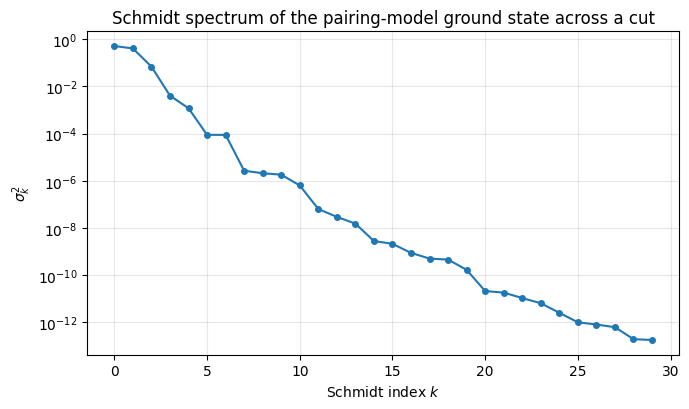

In [26]:
plt.figure(figsize=(7, 4.2))
plt.semilogy(np.maximum(sd.weights[:30], 1e-18), "o-", ms=4)
plt.xlabel(r"Schmidt index $k$")
plt.ylabel(r"$\sigma_k^2$")
plt.title("Schmidt spectrum of the pairing-model ground state across a cut")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Natural orbitals and occupation numbers

For two identical particles the same decomposition has another name.  Writing
$\Psi(x_1,x_2)=\sum_{pq}C_{pq}\varphi_p(x_1)\varphi_q(x_2)$ with
$\boldsymbol{C}$ symmetric, the SVD gives the natural expansion

$$
\Psi(x_1,x_2)=\sum_k \sigma_k\,\chi_k(x_1)\chi_k(x_2),
$$

whose orbitals $\chi_k$ are Löwdin's **natural orbitals** — the eigenvectors of
the one-body density matrix — and whose $\sigma_k^2$ are the **occupation
numbers**.  A single Slater determinant has $N$ occupations equal to one and
the rest zero; correlation depletes them.

We test this on two particles in a harmonic trap with a softened Coulomb
repulsion, diagonalising the full two-particle problem on a grid.

In [27]:
def two_particles_in_a_trap(n=40, rmax=5.0, strength=2.0, softening=0.5):
    """Two particles in a 1D harmonic trap, solved in the product basis."""
    h = 2.0 * rmax / (n + 1)
    x = -rmax + h * np.arange(1, n + 1)

    h1 = np.diag(2.0 / h**2 + x**2)
    off = -1.0 / h**2
    h1 += np.diag(np.full(n-1, off), 1) + np.diag(np.full(n-1, off), -1)

    I = np.eye(n)
    H = np.kron(h1, I) + np.kron(I, h1)
    H += np.diag((strength / np.sqrt((x[:, None]-x[None, :])**2
                                     + softening**2)).ravel())

    values, vectors = np.linalg.eigh(H)
    C = vectors[:, 0].reshape(n, n)
    C = 0.5 * (C + C.T)                       # the ground state is symmetric
    return values[0], C / np.linalg.norm(C), x


print(f"{'g':>5s} {'E_0':>12s} {'entropy':>11s} {'n_0':>10s} {'n_1':>10s} "
      f"{'n_2':>11s} {'chi for 1e-8':>13s}")
print("-" * 76)
orbitals = {}
for g in (0.0, 1.0, 2.0, 5.0):
    E0, C, x = two_particles_in_a_trap(strength=g)
    s = SchmidtDecomposition(C)
    orbitals[g] = (x, s)
    print(f"{g:5.1f} {E0:12.6f} {s.entanglement_entropy():11.6f} "
          f"{s.weights[0]:10.6f} {s.weights[1]:10.6f} {s.weights[2]:11.3e} "
          f"{s.states_for(1e-8):13d}")
print("-" * 76)
print("At g = 0 the state is a product: one natural orbital, zero entropy.")

    g          E_0     entropy        n_0        n_1         n_2  chi for 1e-8
----------------------------------------------------------------------------


  0.0     1.992536    0.000000   1.000000   0.000000   3.157e-30             1


  1.0     3.173866    0.040874   0.993528   0.006017   4.153e-04            10


  2.0     4.245117    0.139618   0.970732   0.027407   1.747e-03            11


  5.0     6.755062    0.507970   0.821806   0.168066   1.006e-02            11
----------------------------------------------------------------------------
At g = 0 the state is a product: one natural orbital, zero entropy.


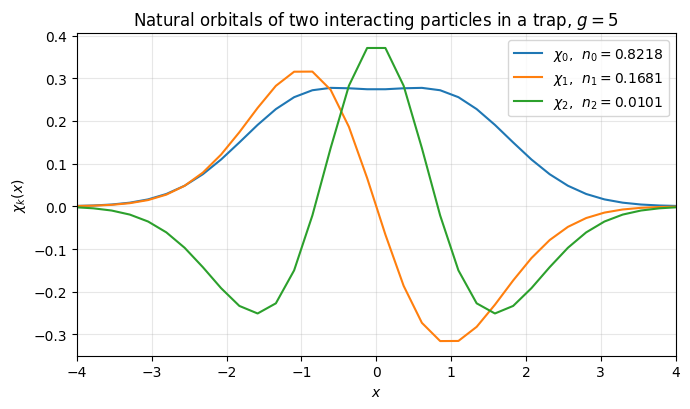

In [28]:
x, s = orbitals[5.0]
plt.figure(figsize=(7, 4.2))
for k in range(3):
    chi = s.U[:, k]
    if chi[np.argmax(np.abs(chi))] < 0:
        chi = -chi
    plt.plot(x, chi, label=fr"$\chi_{k}$,  $n_{k}={s.weights[k]:.4f}$")
plt.xlim(-4, 4)
plt.xlabel("$x$")
plt.ylabel(r"$\chi_k(x)$")
plt.title("Natural orbitals of two interacting particles in a trap, $g=5$")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Low-rank factorisation of the two-body interaction

The last application concerns the Hamiltonian rather than the state.  Reading
the pairs $(pq)$ and $(rs)$ as composite indices turns the four-index array
$V_{pqrs}$ into an ordinary matrix, positive semidefinite for a Coulomb-like
kernel, so that

$$
V_{(pq),(rs)} = \sum_{\gamma=0}^{M-1} L^{\gamma}_{pq} L^{\gamma}_{rs} .
$$

Because the pair densities $\varphi_p\varphi_q$ are far from linearly
independent, the eigenvalues decay geometrically and $M \ll n^2$.  This is the
Cholesky decomposition of the two-electron integrals, or density fitting;
applying the idea a second time to each $L^\gamma$ gives the double
factorisation used to cut the term count in VQE and qubitisation Hamiltonians.

In [29]:
w, U = np.linalg.eigh(0.5 * (V2b + V2b.T))
order = np.argsort(w)[::-1]
w, U = w[order], U[:, order]


def reconstruct(M):
    L = (U[:, :M] * np.sqrt(np.maximum(w[:M], 0.0))).T
    return L.T @ L


tail = np.cumsum(w[::-1])[::-1]
print(f"number of pair indices (n_orb^2): {V2b.shape[0]}")
print(f"{'target weight':>15s} {'vectors M':>11s} {'|V - L^T L|/|V|':>18s}")
for tol in (1e-4, 1e-6, 1e-8):
    M = int(np.where(tail <= tol * np.sum(np.maximum(w, 0)))[0][0])
    err = np.linalg.norm(reconstruct(M) - V2b) / np.linalg.norm(V2b)
    print(f"{tol:15.0e} {M:11d} {err:18.2e}")
print("\nleading eigenvalues of the pair matrix:")
print(" ", np.array2string(w[:8], precision=4))

number of pair indices (n_orb^2): 144
  target weight   vectors M    |V - L^T L|/|V|
          1e-04           7           2.08e-05
          1e-06           9           1.70e-07
          1e-08          10           1.17e-08

leading eigenvalues of the pair matrix:
  [44.6814 15.6283  5.1839  1.3778  0.3086  0.0554  0.0082  0.001 ]


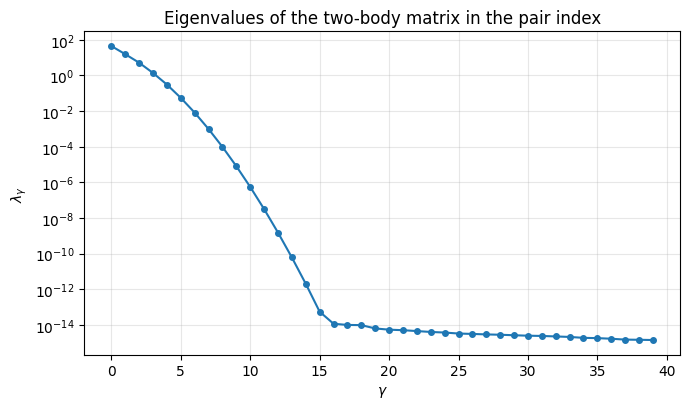

In [30]:
plt.figure(figsize=(7, 4.2))
plt.semilogy(np.maximum(w[:40], 1e-18), "o-", ms=4)
plt.xlabel(r"$\gamma$")
plt.ylabel(r"$\lambda_\gamma$")
plt.title("Eigenvalues of the two-body matrix in the pair index")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### What the singular values were telling us

One decomposition, read five ways.  The same list of numbers gave the numerical
rank of a matrix, the distance of a basis from linear dependence, the weight
lost in truncating a wave function, the entanglement across a cut, the
occupation of the natural orbitals, and the number of auxiliary vectors needed
for a two-body interaction.

The thread is the Eckart-Young theorem: keeping the largest singular values is
the best approximation of its rank that exists.  That single statement is the
justification for natural-orbital truncation, for density fitting, and for the
density-matrix renormalisation group — and, read in reverse, it is what tells
us when a state is *not* compressible and a quantum computer might be needed.

## Where this leads

Expanding a state in a finite basis and diagonalising the resulting matrix is
exactly what full configuration interaction does.  The only differences are
that the basis consists of Slater determinants rather than grid points, and
that its dimension grows exponentially with the number of particles rather
than linearly with the number of mesh points.  That is why the Lanczos
algorithm of section 4, and not the direct diagonalisation of section 3, is
the method used in large-scale many-body calculations.